In [1]:
import pandas as pd
from CCA_utils import *

## Theta ETA estimation

In [2]:
study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']

cca_panel_df = pd.read_csv('cca_panel_newdebt.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()


oil_prices = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
oil_prices['Date'] = pd.to_datetime(oil_prices['Date'])

cca_panel_df = cca_panel_df.merge(oil_prices[['Date','Brent']], left_on='date', right_on='Date', how='left')


cca_panel_df.drop(columns=['cds_spread_1Y'], inplace=True)
cca_panel_df.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)

T=1.0
vol_window = 52
freq = 'W'


/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_39369/3752709599.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_prices['Date'] = pd.to_datetime(oil_prices['Date'])


In [3]:

T=1.0
vol_window = 52
freq = 'W'

#This replace with msci corr with oil returns.
RHO_DEFAULT = 0.25

MSCI_EM_constituent_list = [ "Brazil", "Chile", "China", "Colombia", "Czechia", "Egypt",
                             "Greece", "Hungary", "India", "Indonesia", "South Korea", "Kuwait", 
                             "Malaysia", "Mexico", "Peru", "Philippines", "Poland", "Qatar",
                            "Saudi Arabia", "South Africa", "Taiwan", "Thailand", "Turkey", "United Arab Emirates"]


THETA_MAP = {
    "Brazil":0.026, "Chile":0, "China":0.003, "Colombia":0.034, "Czechia":0, 
    "Egypt":0.03, "Greece":0, "Hungary":0.02, "India":0.03, "Indonesia":0.008,
    "South Korea":0.1, "Kuwait":0.276, "Malaysia":0.18, "Mexico":0.021, 
    "Peru":0.002, "Philippines":0, "Poland":0, "Qatar":0.153,
    "Saudi Arabia":0.237, "South Africa":0.004, "Taiwan":0, 
    "Thailand":0.005, "Turkey":0.001, "Dubai":0.167, "Abu Dhabi":0.167}



In [10]:

results = pd.DataFrame()



for country, group in cca_panel_df.groupby('country'):
    theta = 0.75 # Default to 0.1 if country not in map

    df = group.copy().sort_values('date').reset_index(drop=True)
    
        # --- Unit conversions ---
    r_d = df['domestic_rate_in_units'] / 100
    r_f = df['risk_free_rate'] / 100
    M_bn = df['monetary_base_mn_localcurr'] / 1000


    # --- LCL$ ---
    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(
            M_bn, df['domestic_debt_bn_localcurr'],
            df['fx_rate'], r_d, r_f
        )
    ]

        # --- Barrier ---
    df['B_f'] = [
            compute_barrier_kvm(debt, rf, T)
            for debt, rf in zip(
                df['external_debt_mn_usd'], r_f
            )
        ]
    
    #estimate eta for this country
    r_msci = np.log(df['msci_index'] / df['msci_index'].shift(1))
    r_oil = np.log(df['Brent'] / df['Brent'].shift(1))
    eta = 0#estimate_eta(r_msci, r_oil)

        # --- Oil reference price (rolling 2-year average) ---
    df['P_oil_ref'] = df['Brent'].rolling(window=12, min_periods=12).mean()

    # --- Augment LCL ---
    df['LCL_aug'] = df.apply(
        lambda row: augment_lcl(row['LCL_usd'], row['Brent'], row['P_oil_ref'],
                                theta, eta)[0]
        if not np.isnan(row['P_oil_ref']) and row['P_oil_ref'] > 0
        else row['LCL_usd'],
        axis=1
    )
    df['LCL_multiplier'] = df['LCL_aug'] / df['LCL_usd']

    ann_factor = np.sqrt(52) if freq == 'W' else np.sqrt(12)
    log_ret = np.log(df['LCL_aug'] / df['LCL_aug'].shift(1))
    
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor

    # --- Solve CCA with augmented LCL ---
    out = {k: [] for k in ['implied_V', 'implied_sigma_V', 'cca_converged',
                            'distance_to_distress', 'default_prob',
                            'model_spread_bps', 'put_value', 'risky_debt',
                            'leverage']}

    for i, row in df.iterrows():
        cca = solve_CCA(row['LCL_aug'], row['sigma_lcl'], row['B_f'],
                        r_f.iloc[i], T)
        risk = compute_risk(cca['V'], cca['sigma_V'], row['B_f'],
                           r_f.iloc[i], T)

        out['implied_V'].append(cca['V'])
        out['implied_sigma_V'].append(cca['sigma_V'])
        out['cca_converged'].append(cca['converged'])
        out['distance_to_distress'].append(risk['d2'])
        out['default_prob'].append(risk['default_prob'])
        out['model_spread_bps'].append(risk['credit_spread_bps'])
        out['put_value'].append(risk['put_value'])
        out['risky_debt'].append(risk['risky_debt'])
        out['leverage'].append(risk['leverage'])

    for col, vals in out.items():
        df[col] = vals

    # Store eta metadata
    df['theta'] = theta
    df['eta'] = eta
    results = pd.concat([results, df])


START_DATE = '2014-01-01'
END_DATE = '2024-12-31'

results = results[
    (results['date'] >= START_DATE) & (results['date'] <= END_DATE)
].copy()


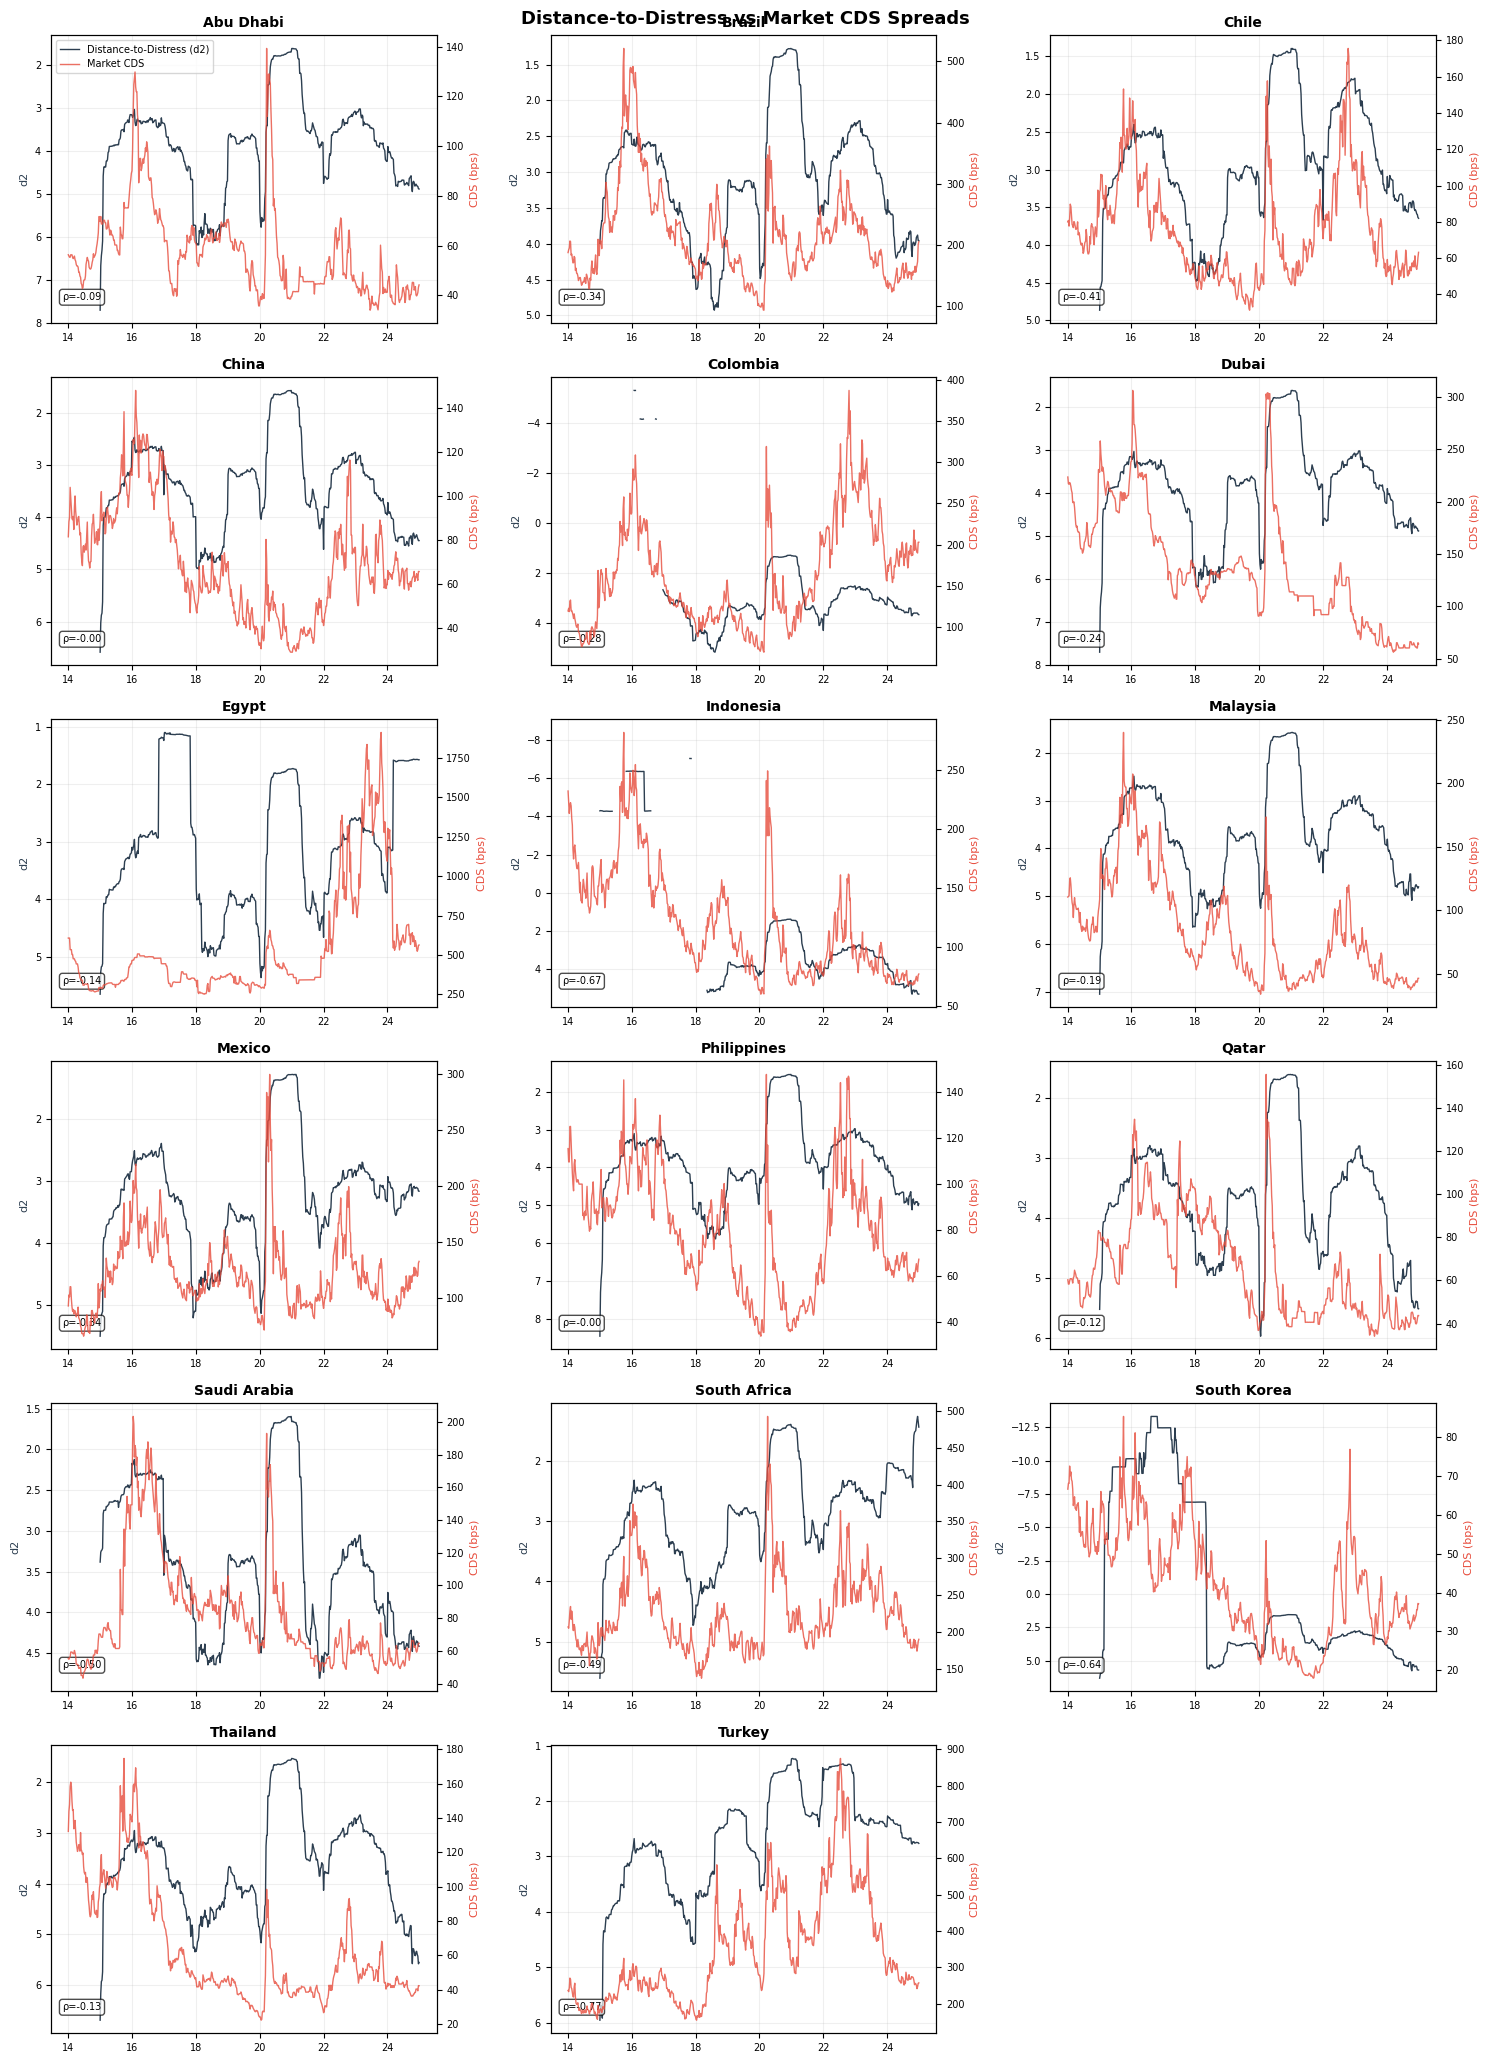

In [11]:
d2_vs_cds = plot_d2_vs_cds(results)

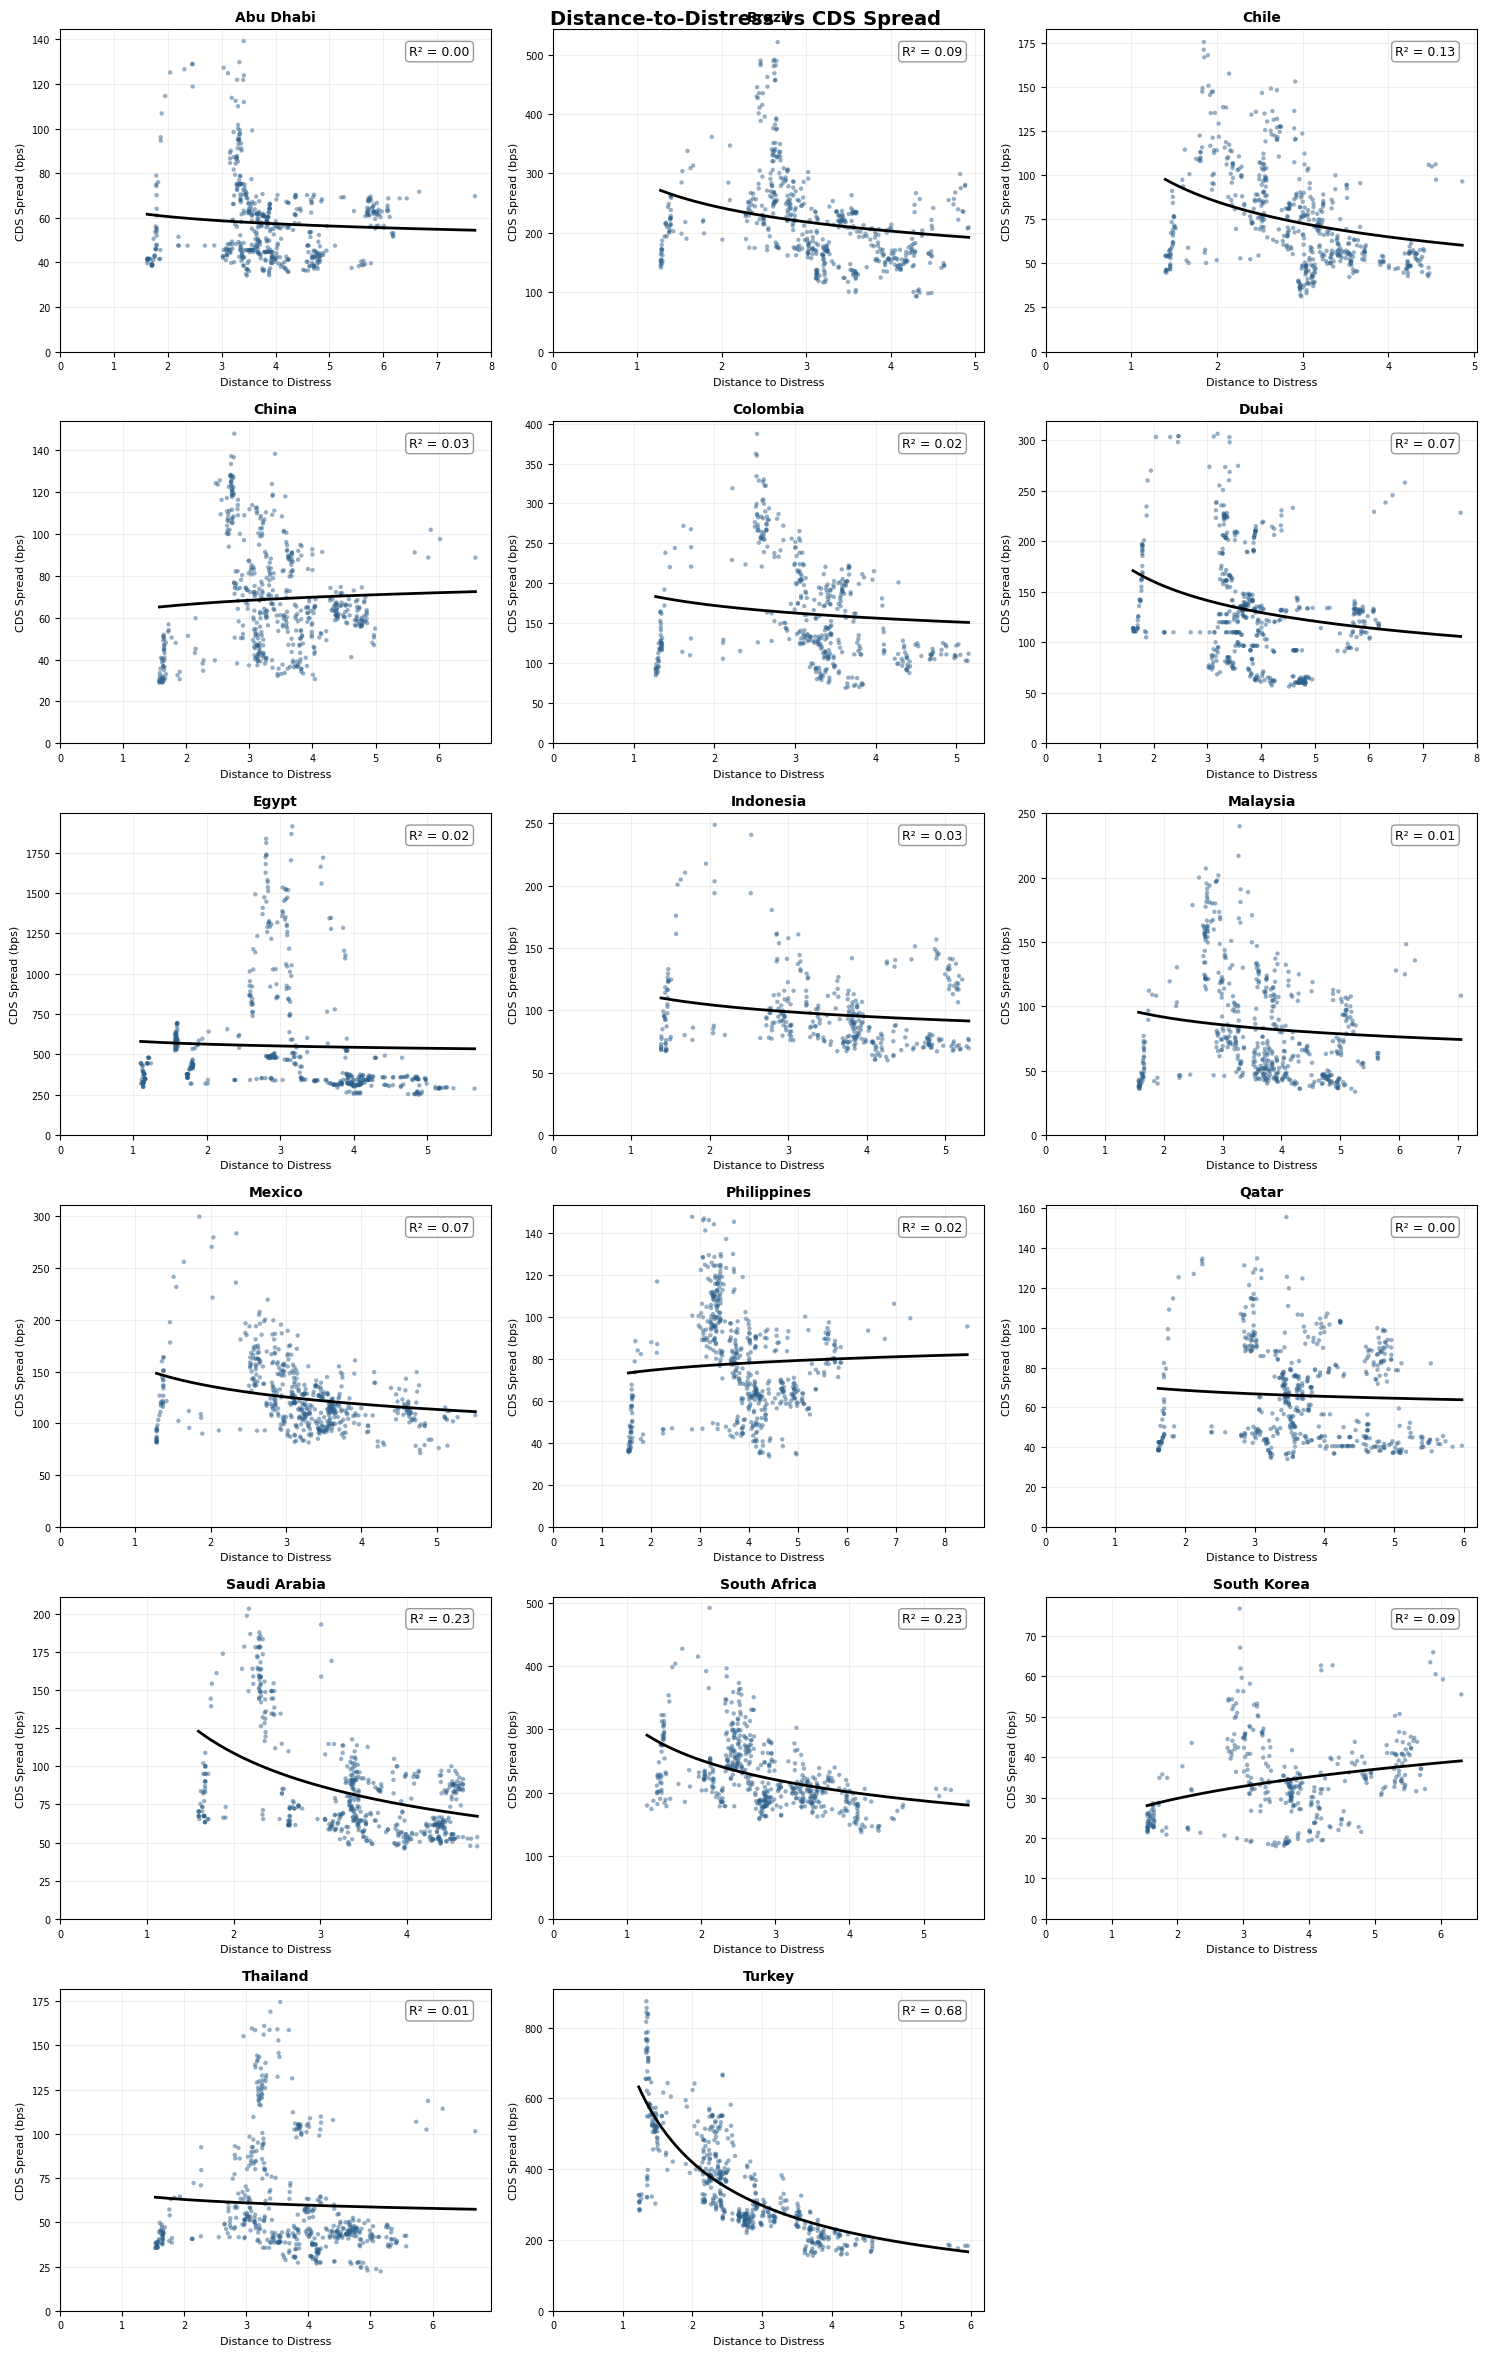

In [13]:
d2_scatter = plot_d2_scatter(results)

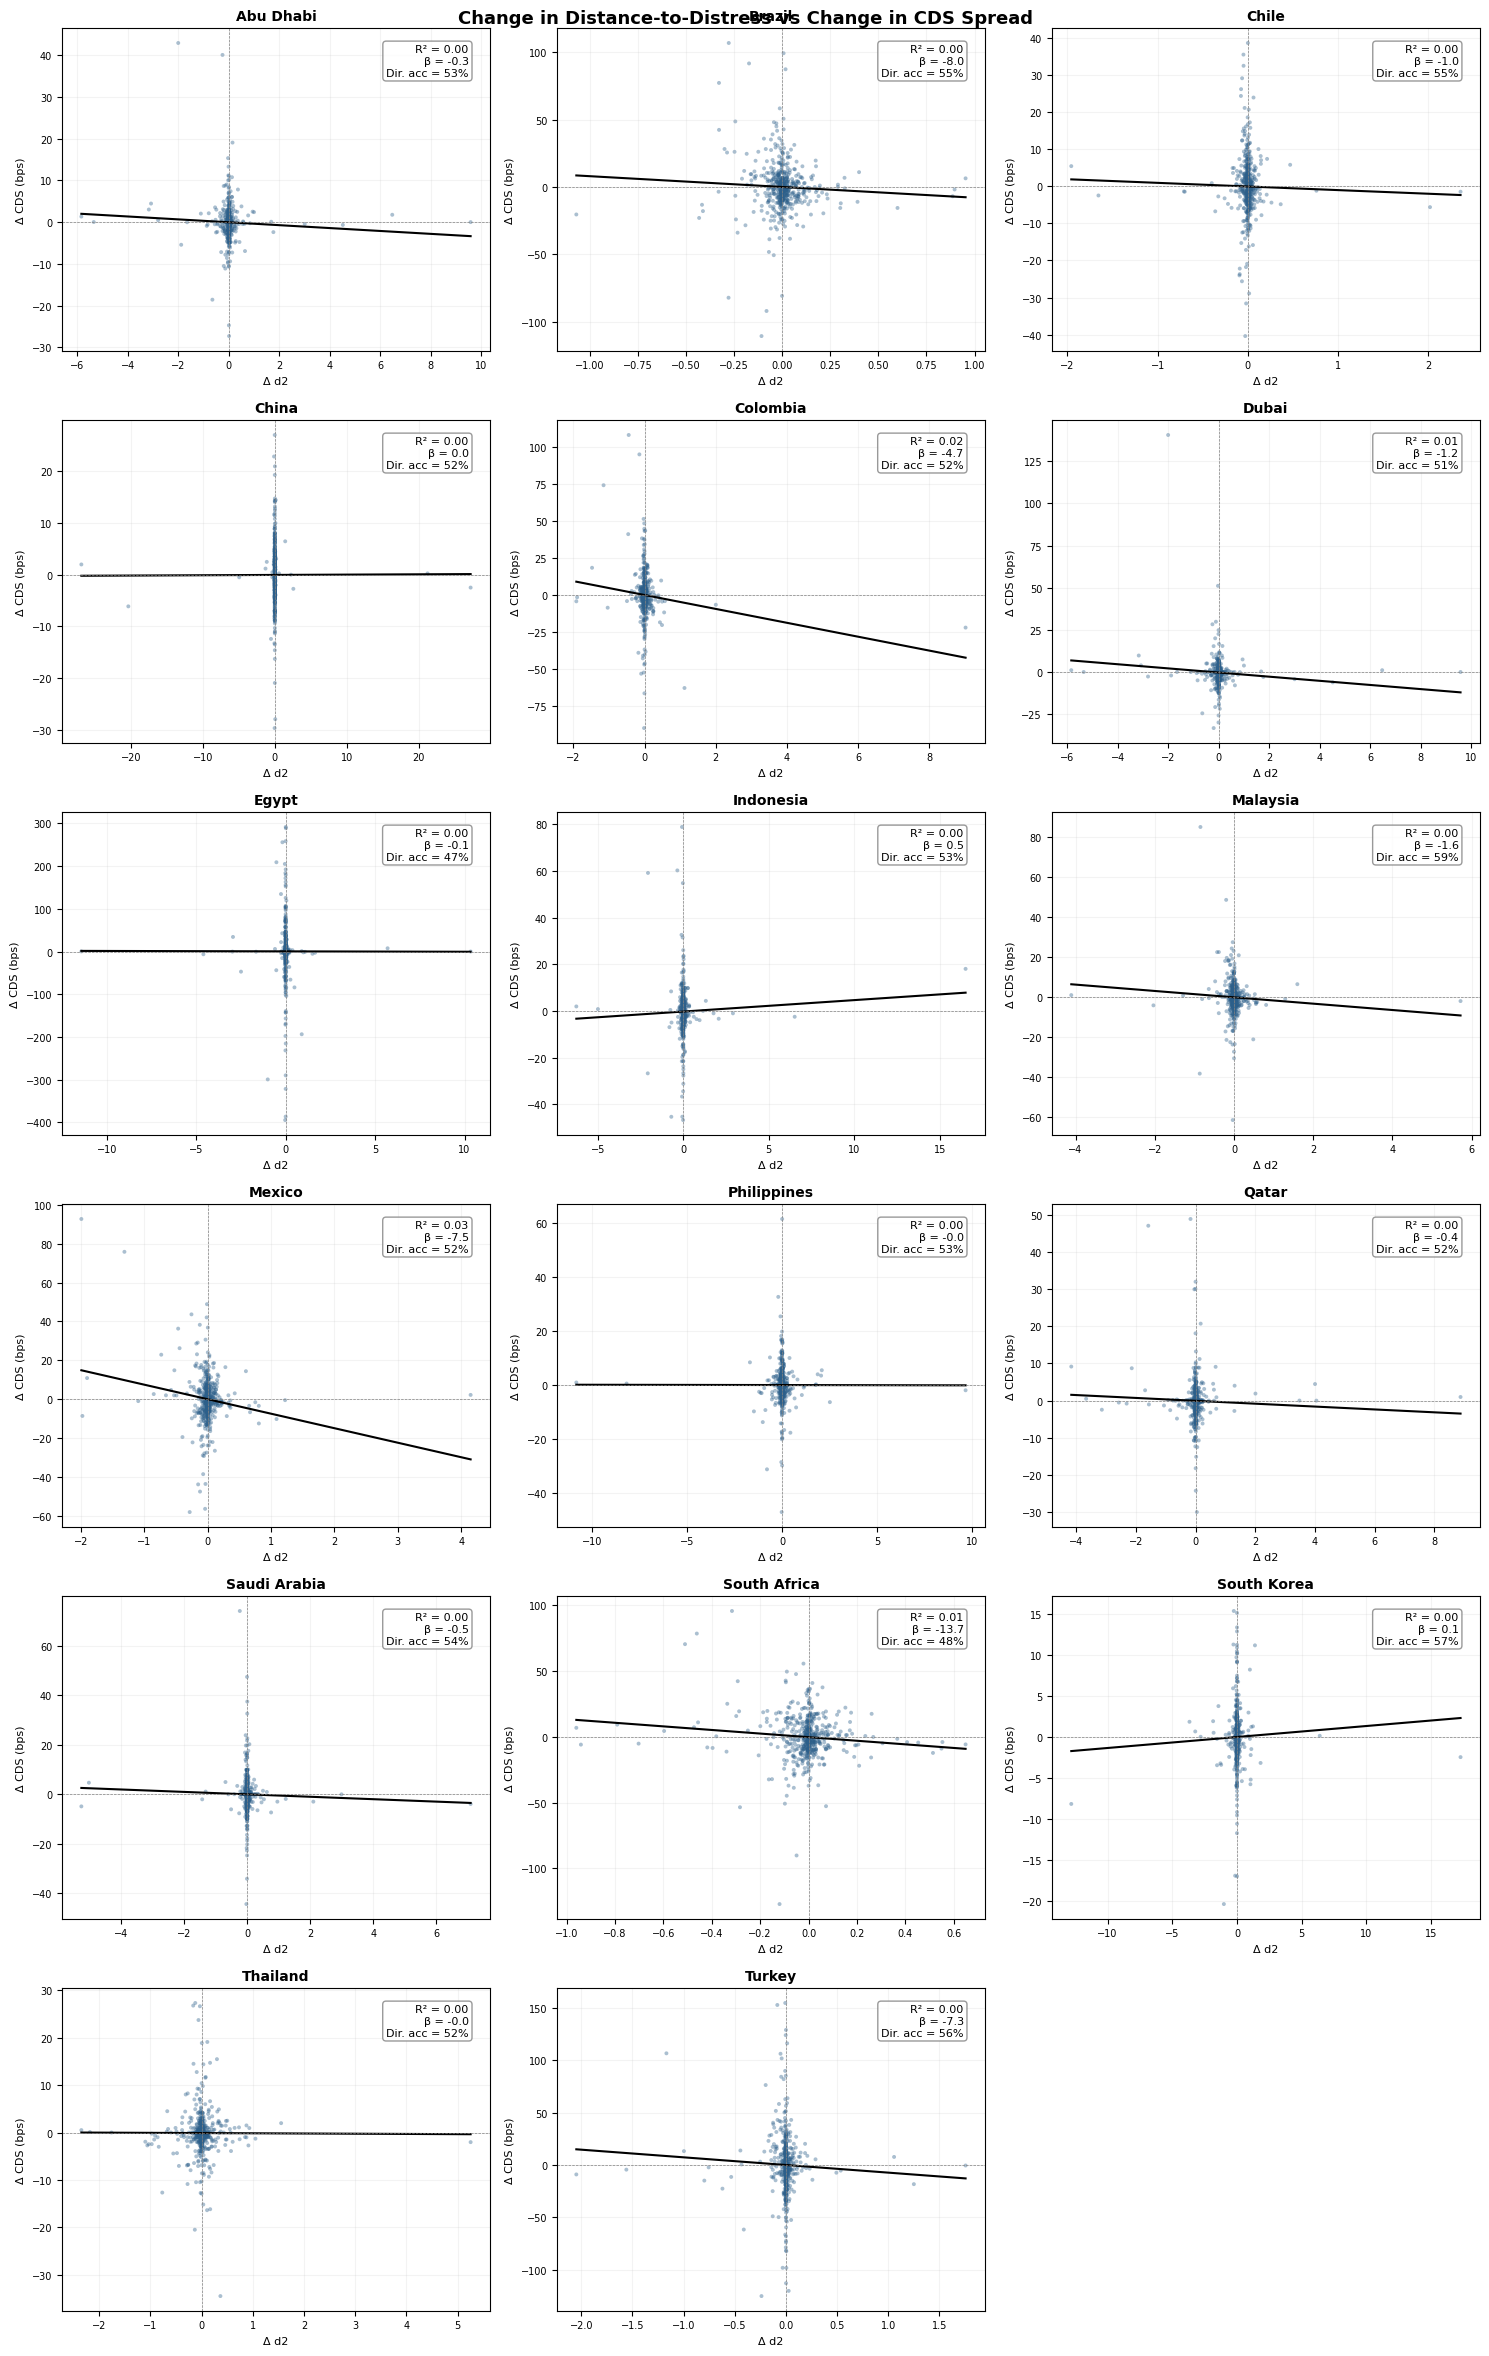

In [14]:
changes = plot_changes(results)

In [26]:
results

,country,date,year,quarter,month,week,cds_spread,fx_rate,msci_index,monetary_base_mn_localcurr,...,implied_sigma_V,cca_converged,distance_to_distress,default_prob,model_spread_bps,put_value,risky_debt,leverage,theta,eta
0,Abu Dhabi,2014-01-03,2014,1.0,1.0,1.0,7.12000,3.672000,749.581,288310.000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.000563
1,Abu Dhabi,2014-01-10,2014,1.0,1.0,2.0,6.62000,3.672000,771.135,288310.000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.000563
2,Abu Dhabi,2014-01-17,2014,1.0,1.0,3.0,6.12000,3.672000,777.754,288310.000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.000563
3,Abu Dhabi,2014-01-24,2014,1.0,1.0,4.0,6.12000,3.672000,808.655,288310.000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.000563
4,Abu Dhabi,2014-01-31,2014,1.0,1.0,5.0,7.12000,3.672000,804.960,288310.000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.000563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,Turkey,2024-11-29,2024,4.0,11.0,48.0,94.17000,34.656799,610.455,6067888.530,...,0.001129,True,3.224224,0.000632,0.001911,0.030000,156986.737896,1.040143,0.0,0.025445
570,Turkey,2024-12-06,2024,4.0,12.0,49.0,90.66000,34.737999,610.777,6585275.534,...,0.001180,True,3.207449,0.000670,0.002126,0.033377,156993.766650,1.038849,0.0,0.025445
571,Turkey,2024-12-13,2024,4.0,12.0,50.0,92.50000,34.943001,644.678,6585275.534,...,0.001174,True,3.205360,0.000674,0.002130,0.033446,156990.591789,1.039394,0.0,0.025445
572,Turkey,2024-12-20,2024,4.0,12.0,51.0,96.20000,35.069801,626.599,6585275.534,...,0.001169,True,3.204870,0.000676,0.002126,0.033381,156988.669671,1.039721,0.0,0.025445
